#A Zwana 22409287

# 1. Introduction, Objectives & Analytical Approach

## 1.1 Problem Statement
Forecasting democratic outcomes at the municipal level in South Africa requires handling sparse longitudinal observations (quadrennial/quinquennial election cycles) and shifting spatial boundaries. The objective of this study is to engineer a technically defensible predictive framework that estimates:
- The dominant aggregate vote share and council majority likelihood in the City of Cape Town for 04 November 2026.
- Categorical winning party projections across three selected wards with distinct demographic and political dynamics.
- Municipal-wide voter turnout rates and total turnout counts.

The focus is placed on model interpretability, error quantification, and defensible handling of boundary changes rather than unverified precision.

## 1.2 Technical Plan of Work
- **Data Acquisition & Normalization:** Source verified municipal election returns from the official IEC data repository. Standardize schema definitions across 2011, 2016, and 2021 LGE datasets, consolidating micro-parties into a bounded `'Other'` class to maintain high signal-to-noise ratios.
- **Spatial Alignment:** Systematically reconcile voting station migrations and ward redistricting between the 2016 and 2021 delimitations to ensure longitudinal comparability in ward-level features.
- **Model Training & Architecture:**
  - Build baseline parametric models (Ridge/Lasso) alongside non-parametric ensemble models (Random Forest, XGBoost) to predict vote margins and turnout percentage.
  - Employ classification algorithms with balanced class weights to predict winner categories in the selected target wards.
- **Evaluation & Uncertainty:** Apply time-aware train/test splitting. Report classification performance using Macro F1-scores, precision-recall curves, and confusion matrices; evaluate continuous share forecasts using Mean Absolute Error (MAE) alongside 95% predictive intervals.
- **Artifact Generation:** Bundle the pipeline into a modular Jupyter Notebook paired with a deployable Streamlit analytics dashboard.

Finding a dataset


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load Datasets from Google Drive

In [22]:
import pandas as pd

# File paths
path_2011_results = '/content/drive/MyDrive/Final-TP-Exam-Aya/jhb_2011_detailed_results.csv'
path_2011_turnout = '/content/drive/MyDrive/Final-TP-Exam-Aya/jhb_2011_voter_turnout.xls'
path_2016_results = '/content/drive/MyDrive/Final-TP-Exam-Aya/jhb_2016_detailed_results.csv'
path_2016_turnout = '/content/drive/MyDrive/Final-TP-Exam-Aya/jhb_2016_voter_turnout.xls'
path_2021_results = '/content/drive/MyDrive/Final-TP-Exam-Aya/jhb_2021_detailed_results.csv'
path_2021_turnout = '/content/drive/MyDrive/Final-TP-Exam-Aya/jhb_2021_voter_turnout.xls'

# Loading the CSV datasets with UTF-16 encoding and fallback
def load_csv(path):
    try:
        # Try UTF-16 with auto separator detection or tab fallback
        return pd.read_csv(path, encoding='utf-16', sep=None, engine='python')
    except Exception:
        # Fallback to UTF-8 if UTF-16 fails
        return pd.read_csv(path, encoding='utf-8')

df_2011_results = load_csv(path_2011_results)
df_2011_turnout = pd.read_excel(path_2011_turnout)

df_2016_results = load_csv(path_2016_results)
df_2016_turnout = pd.read_excel(path_2016_turnout)

df_2021_results = load_csv(path_2021_results)
df_2021_turnout = pd.read_excel(path_2021_turnout)

print("All datasets loaded successfully!")

WARNING *** file size (42156) not 512 + multiple of sector size (512)
WARNING *** file size (40832) not 512 + multiple of sector size (512)
WARNING *** file size (131008) not 512 + multiple of sector size (512)
All datasets loaded successfully!


### Preview Datasets

In [23]:
print("=== 2011 Results ===")
display(df_2011_results.head(2))
print("\n=== 2011 Turnout ===")
display(df_2011_turnout.head(2))

print("\n=== 2016 Results ===")
display(df_2016_results.head(2))
print("\n=== 2016 Turnout ===")
display(df_2016_turnout.head(2))

print("\n=== 2021 Results ===")
display(df_2021_results.head(2))
print("\n=== 2021 Turnout ===")
display(df_2021_turnout.head(2))

=== 2011 Results ===


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,Gauteng,JHB - City of Johannesburg [Johannesburg],Ward 79800001,32860728,TRINITY COMMUNITY CHURCH,2559,PR,22,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,2,5/26/2011 4:39:57 PM
1,Gauteng,JHB - City of Johannesburg [Johannesburg],Ward 79800001,32860728,TRINITY COMMUNITY CHURCH,2559,PR,22,AFRICAN CHRISTIAN DEMOCRATIC PARTY,2,5/26/2011 4:39:57 PM



=== 2011 Turnout ===


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== 2016 Results ===


...

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== 2021 Results ===


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,Gauteng,JHB - City of Johannesburg,Ward 79800001,32860728,THE VICTORIOUS RESTORATION CHURCH INTERNATIONAL,3554,PR,38,ABAHLALY BAAHI,0,11/23/2021 4:24:00 PM
1,Gauteng,JHB - City of Johannesburg,Ward 79800001,32860728,THE VICTORIOUS RESTORATION CHURCH INTERNATIONAL,3554,PR,38,ABANTU BATHO CONGRESS,1,11/23/2021 4:24:00 PM



=== 2021 Turnout ===


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 1: Data Understanding & Pre-processing

### 1.1 Data Exploration & Structure Inspection
Let's check the schema definitions, column names, and unique value distributions for both the detailed results and voter turnout datasets across the three years.

In [24]:
# Print columns for results datasets
print("2011 Results Columns:", df_2011_results.columns.tolist())
print("2016 Results Columns:", df_2016_results.columns.tolist())
print("2021 Results Columns:", df_2021_results.columns.tolist())

# Inspect first few rows of results
display(df_2011_results.head(3))

2011 Results Columns: ['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']
2016 Results Columns: ['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']
2021 Results Columns: ['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,Gauteng,JHB - City of Johannesburg [Johannesburg],Ward 79800001,32860728,TRINITY COMMUNITY CHURCH,2559,PR,22,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,2,5/26/2011 4:39:57 PM
1,Gauteng,JHB - City of Johannesburg [Johannesburg],Ward 79800001,32860728,TRINITY COMMUNITY CHURCH,2559,PR,22,AFRICAN CHRISTIAN DEMOCRATIC PARTY,2,5/26/2011 4:39:57 PM
2,Gauteng,JHB - City of Johannesburg [Johannesburg],Ward 79800001,32860728,TRINITY COMMUNITY CHURCH,2559,PR,22,AFRICAN NATIONAL CONGRESS,1270,5/26/2011 4:39:57 PM


### 1.2 Party Name Standardization
In election datasets, party names often change or use different abbreviations across election cycles. We will discover the most active parties and set up a cleaning mapping to align them (e.g., standardizing 'DEMOCRATIC ALLIANCE' and 'DA' or 'AFRICAN NATIONAL CONGRESS' and 'ANC').

In [25]:
# Inspect top parties by frequency to detect naming mismatches
for year, df in [('2011', df_2011_results), ('2016', df_2016_results), ('2021', df_2021_results)]:
    print(f"\n--- Top 10 Party Names in {year} ---")
    # Adapt column name if party column differs (commonly 'Party' or similar)
    party_col = [col for col in df.columns if 'party' in col.lower()]
    if party_col:
        print(df[party_col[0]].value_counts().head(10))
    else:
        print("Party column not explicitly identified. Available columns:", df.columns.tolist())


--- Top 10 Party Names in 2011 ---
PartyName
AFRICAN NATIONAL CONGRESS                                  1594
CONGRESS  OF THE PEOPLE                                    1594
VRYHEIDSFRONT PLUS                                         1594
UNITED DEMOCRATIC MOVEMENT                                 1594
DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE                 1594
AFRICAN PEOPLE'S CONVENTION                                1587
CHRISTIAN DEMOCRATIC PARTY                                 1587
AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ALLIANSIE    1584
AZANIAN PEOPLE'S ORGANISATION                              1575
PAN AFRICANIST CONGRESS OF AZANIA                          1562
Name: count, dtype: int64

--- Top 10 Party Names in 2016 ---
PartyName
AFRICAN NATIONAL CONGRESS             1684
DEMOCRATIC ALLIANCE                   1684
TRULY ALLIANCE                        1684
ECONOMIC FREEDOM FIGHTERS             1684
VRYHEIDSFRONT PLUS                    1684
UNITED DEMOCRATIC MOVEMENT 

### 1.3 Geographic Alignment Analysis (Ward Reconciliation)
We will analyze the consistency of Ward identifiers across 2011, 2016, and 2021 to assess spatial boundary stability or redistricting shifts.

In [26]:
# Analyze unique wards in each election cycle
wards_2011 = set(df_2011_results['Ward'].dropna().unique())
wards_2016 = set(df_2016_results['Ward'].dropna().unique())
wards_2021 = set(df_2021_results['Ward'].dropna().unique())

print(f"Number of unique wards in 2011: {len(wards_2011)}")
print(f"Number of unique wards in 2016: {len(wards_2016)}")
print(f"Number of unique wards in 2021: {len(wards_2021)}")

# Intersection/Overlay analysis
overlap_11_16 = wards_2011.intersection(wards_2016)
overlap_16_21 = wards_2016.intersection(wards_2021)
overlap_all = wards_2011.intersection(wards_2016).intersection(wards_2021)

print(f"\nWards common to 2011 & 2016: {len(overlap_11_16)}")
print(f"Wards common to 2016 & 2021: {len(overlap_16_21)}")
print(f"Wards common across all three periods: {len(overlap_all)}")

Number of unique wards in 2011: 130
Number of unique wards in 2016: 135
Number of unique wards in 2021: 135

Wards common to 2011 & 2016: 130
Wards common to 2016 & 2021: 135
Wards common across all three periods: 130


### 1.4 Mapping and Standardizing Party Names
We will map the historical names of key parties to standard labels ('ANC', 'DA', 'EFF', 'VF+', 'Other'). This eliminates name changes or translations (e.g. 'DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE' -> 'DA') and filters down to high-signal groups.

In [27]:
def standardize_and_clean_parties(df):
    df_clean = df.copy()

    # Dictionary of standard mappings
    party_mapping = {
        'AFRICAN NATIONAL CONGRESS': 'ANC',
        'DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE': 'DA',
        'DEMOCRATIC ALLIANCE': 'DA',
        'ECONOMIC FREEDOM FIGHTERS': 'EFF',
        'VRYHEIDSFRONT PLUS': 'VF+',
        'FREEDOM FRONT PLUS': 'VF+'
    }

    # Apply mapping, default to 'Other' for minor parties
    df_clean['StandardParty'] = df_clean['PartyName'].map(party_mapping).fillna('Other')
    return df_clean

df_2011_cleaned = standardize_and_clean_parties(df_2011_results)
df_2016_cleaned = standardize_and_clean_parties(df_2016_results)
df_2021_cleaned = standardize_and_clean_parties(df_2021_results)

# Quick confirmation check
print("2011 unique standard parties:", df_2011_cleaned['StandardParty'].unique())
print("2021 unique standard parties:", df_2021_cleaned['StandardParty'].unique())

2011 unique standard parties: ['Other' 'ANC' 'DA' 'VF+']
2021 unique standard parties: ['Other' 'ANC' 'DA' 'EFF' 'VF+']


### 1.5 Consolidating Party Performance by Ward
Next, we aggregate total valid votes per Ward for each standardized party group. We will pivot this table to create a clean Ward-level master dataset for vote share comparison across the years.

In [28]:
def get_ward_party_shares(df, year):
    # Group and aggregate
    grouped = df.groupby(['Ward', 'StandardParty'])['TotalValidVotes'].sum().reset_index()

    # Pivot to get parties as columns
    pivoted = grouped.pivot(index='Ward', columns='StandardParty', values='TotalValidVotes').fillna(0)

    # Calculate total votes and percentage shares
    pivoted['TotalVotes'] = pivoted.sum(axis=1)
    for col in ['ANC', 'DA', 'EFF', 'VF+', 'Other']:
        if col in pivoted.columns:
            pivoted[f'{col}_Share'] = pivoted[col] / pivoted['TotalVotes']
        else:
            pivoted[f'{col}_Share'] = 0.0

    pivoted = pivoted.reset_index()
    pivoted['Year'] = year
    return pivoted

ward_shares_2011 = get_ward_party_shares(df_2011_cleaned, 2011)
ward_shares_2016 = get_ward_party_shares(df_2016_cleaned, 2016)
ward_shares_2021 = get_ward_party_shares(df_2021_cleaned, 2021)

print("2021 Ward-Level Party Shares:")
display(ward_shares_2021.head(3))

2021 Ward-Level Party Shares:


StandardParty,Ward,ANC,DA,EFF,Other,VF+,TotalVotes,ANC_Share,DA_Share,EFF_Share,VF+_Share,Other_Share,Year
0,Ward 79800001,6284,703,1554,2087,11,10639,0.590657,0.066078,0.146066,0.001034,0.196165,2021
1,Ward 79800002,5271,1153,2697,1403,15,10539,0.500142,0.109403,0.255907,0.001423,0.133125,2021
2,Ward 79800003,5978,598,2105,1934,7,10622,0.562794,0.056298,0.198174,0.000659,0.182075,2021


### 1.6 Handling Geographic Ward Alignment
As shown in the analysis, there is a discrepancy in the number of wards (130 wards in 2011 vs 135 in 2016 and 2021). To model longitudinal changes reliably:
- We will focus our predictive analysis primarily on the **130 wards** that have remained active and consistent across all three cycles.
- New wards created after 2011 can either be excluded from long-term comparisons or evaluated specifically within 2016-2021 dynamics. We will subset our comparative master dataset to the intersecting 130 wards.

In [29]:
common_wards = list(overlap_all)
print(f"Filtering all datasets to use the {len(common_wards)} common wards...")

master_shares_2011 = ward_shares_2011[ward_shares_2011['Ward'].isin(common_wards)]
master_shares_2016 = ward_shares_2016[ward_shares_2016['Ward'].isin(common_wards)]
master_shares_2021 = ward_shares_2021[ward_shares_2021['Ward'].isin(common_wards)]

print(f"Master aligned dataset sizes: 2011 ({len(master_shares_2011)}), 2016 ({len(master_shares_2016)}), 2021 ({len(master_shares_2021)})")

Filtering all datasets to use the 130 common wards...
Master aligned dataset sizes: 2011 (130), 2016 (130), 2021 (130)


### 1.7 Inspecting and Cleaning Voter Turnout Data
The voter turnout datasets are stored as Excel spreadsheets with metadata in the header rows. Let's inspect the columns of the raw turnout DataFrames to locate where the Ward ID, Registered Voters, and Turnout Percentage/Values reside, and write a function to clean them.

In [30]:
# Print raw columns or non-null structures of turnout sheets
print("--- 2011 Turnout Sheet Raw Sample ---")
display(df_2011_turnout.iloc[2:10])

print("\n--- 2021 Turnout Sheet Raw Sample ---")
display(df_2021_turnout.iloc[2:10])

--- 2011 Turnout Sheet Raw Sample ---


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
2,NaN,NaN,NaN,NaN,Voter Turnout Report,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,Printed on: 2011/05/26 16:33:44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,Local Government Elections 2011,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,Province:,Gauteng,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,Municipality:,JHB - City of Johannesburg [Johannesburg],NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,Ward:,All Wards,NaN,NaN,NaN,NaN,NaN



--- 2021 Turnout Sheet Raw Sample ---


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,Up,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Voter Turnout Report,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Printed on: 2021/11/22 16:50:53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,LOCAL GOVERNMENT ELECTION 2021,NaN,NaN,NaN,NaN,NaN


### 1.8 Parsing and Extracting Turnout Rates
Based on the raw tables, we will locate the actual row containing column headers and parse each spreadsheet properly into clean tables containing: `Ward`, `Registered_Voters`, and `Turnout_Percentage`.

In [31]:
def parse_turnout_sheet(df, year):
    # Find the row that contains header-like names, typically has 'Ward' or 'Registered' in it
    header_row_idx = None
    for idx, row in df.iterrows():
        row_strs = [str(val).lower() for val in row.values]
        if any('ward' in s for s in row_strs) and any('registered' in s or 'voters' in s for s in row_strs):
            header_row_idx = idx
            break

    if header_row_idx is None:
        raise ValueError(f"Could not identify header row automatically in {year} turnout sheet.")

    # Slice the dataframe to start from the header row
    clean_df = df.iloc[header_row_idx + 1:].copy()
    clean_df.columns = df.iloc[header_row_idx].astype(str).str.strip().tolist()

    # Find exact column names via patterns
    ward_col = [c for c in clean_df.columns if 'ward' in c.lower()][0]
    voters_col = [c for c in clean_df.columns if 'registered' in c.lower() or 'voters' in c.lower()][0]
    turnout_col = [c for c in clean_df.columns if 'turnout' in c.lower() or '%' in c.lower() or 'percentage' in c.lower()][0]

    # Clean and subset
    clean_df = clean_df[[ward_col, voters_col, turnout_col]].dropna()
    clean_df.columns = ['Ward', 'Registered_Voters', 'Turnout_Percentage']

    # Ensure data types are numeric and Ward IDs are formatted consistently
    clean_df['Ward'] = clean_df['Ward'].astype(str).str.strip()
    clean_df['Registered_Voters'] = pd.to_numeric(clean_df['Registered_Voters'], errors='coerce')
    clean_df['Turnout_Percentage'] = pd.to_numeric(clean_df['Turnout_Percentage'], errors='coerce')

    # Adjust decimal turnout ratios to percentage if needed
    if clean_df['Turnout_Percentage'].max() <= 1.0:
        clean_df['Turnout_Percentage'] = clean_df['Turnout_Percentage'] * 100.0

    clean_df['Year'] = year
    return clean_df

# Run parsing function
turnout_2011 = parse_turnout_sheet(df_2011_turnout, 2011)
turnout_2016 = parse_turnout_sheet(df_2016_turnout, 2016)
turnout_2021 = parse_turnout_sheet(df_2021_turnout, 2021)

print("Turnout datasets parsed successfully!")
display(turnout_2021.head(3))

Turnout datasets parsed successfully!


,Ward,Registered_Voters,Turnout_Percentage,Year
21,Ward,NaN,NaN,2021
22,79800001,79800001.0,79800001.0,2021
23,79800002,79800002.0,79800002.0,2021


### 1.7 Inspecting and Cleaning Voter Turnout Data
The voter turnout datasets are stored as Excel spreadsheets with metadata in the header rows. Let's inspect the columns of the raw turnout DataFrames to locate where the Ward ID, Registered Voters, and Turnout Percentage/Values reside, and write a function to clean them.

In [32]:
# Print raw columns or non-null structures of turnout sheets
print("--- 2011 Turnout Sheet Raw Sample ---")
display(df_2011_turnout.iloc[2:10])

print("\n--- 2021 Turnout Sheet Raw Sample ---")
display(df_2021_turnout.iloc[2:10])

--- 2011 Turnout Sheet Raw Sample ---


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
2,NaN,NaN,NaN,NaN,Voter Turnout Report,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,Printed on: 2011/05/26 16:33:44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,Local Government Elections 2011,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,Province:,Gauteng,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,Municipality:,JHB - City of Johannesburg [Johannesburg],NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,Ward:,All Wards,NaN,NaN,NaN,NaN,NaN



--- 2021 Turnout Sheet Raw Sample ---


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,Up,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Voter Turnout Report,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Printed on: 2021/11/22 16:50:53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,LOCAL GOVERNMENT ELECTION 2021,NaN,NaN,NaN,NaN,NaN


### 1.8 Parsing and Extracting Turnout Rates
Based on the raw tables, we will locate the actual row containing column headers and parse each spreadsheet properly into clean tables containing: `Ward`, `Registered_Voters`, and `Turnout_Percentage`.

In [33]:
def parse_turnout_sheet(df, year):
    # Find the row that contains header-like names, typically has 'Ward' or 'Registered' in it
    header_row_idx = None
    for idx, row in df.iterrows():
        row_strs = [str(val).lower() for val in row.values]
        if any('ward' in s for s in row_strs) and any('registered' in s or 'voters' in s for s in row_strs):
            header_row_idx = idx
            break

    if header_row_idx is None:
        raise ValueError(f"Could not identify header row automatically in {year} turnout sheet.")

    # Slice the dataframe to start from the header row
    clean_df = df.iloc[header_row_idx + 1:].copy()
    clean_df.columns = df.iloc[header_row_idx].astype(str).str.strip().tolist()

    # Find exact column names via patterns
    ward_col = [c for c in clean_df.columns if 'ward' in c.lower()][0]
    voters_col = [c for c in clean_df.columns if 'registered' in c.lower() or 'voters' in c.lower()][0]
    turnout_col = [c for c in clean_df.columns if 'turnout' in c.lower() or '%' in c.lower() or 'percentage' in c.lower()][0]

    # Clean and subset
    clean_df = clean_df[[ward_col, voters_col, turnout_col]].dropna()
    clean_df.columns = ['Ward', 'Registered_Voters', 'Turnout_Percentage']

    # Ensure data types are numeric and Ward IDs are formatted consistently
    clean_df['Ward'] = clean_df['Ward'].astype(str).str.strip()
    clean_df['Registered_Voters'] = pd.to_numeric(clean_df['Registered_Voters'], errors='coerce')
    clean_df['Turnout_Percentage'] = pd.to_numeric(clean_df['Turnout_Percentage'], errors='coerce')

    # Adjust decimal turnout ratios to percentage if needed
    if clean_df['Turnout_Percentage'].max() <= 1.0:
        clean_df['Turnout_Percentage'] = clean_df['Turnout_Percentage'] * 100.0

    clean_df['Year'] = year
    return clean_df

# Run parsing function
turnout_2011 = parse_turnout_sheet(df_2011_turnout, 2011)
turnout_2016 = parse_turnout_sheet(df_2016_turnout, 2016)
turnout_2021 = parse_turnout_sheet(df_2021_turnout, 2021)

print("Turnout datasets parsed successfully!")
display(turnout_2021.head(3))

Turnout datasets parsed successfully!


,Ward,Registered_Voters,Turnout_Percentage,Year
21,Ward,NaN,NaN,2021
22,79800001,79800001.0,79800001.0,2021
23,79800002,79800002.0,79800002.0,2021


### 1.7 Cleaning and Consolidating Voter Turnout Data
The voter turnout datasets are stored as Excel spreadsheets with metadata in the header rows. Let's inspect the columns of the raw turnout DataFrames to locate where the Ward ID, Registered Voters, and Turnout Percentage/Values reside, and write a function to clean them.

In [34]:
# Print raw column definitions or non-null structures of turnout sheets
print("--- 2011 Turnout Sheet Raw Sample ---")
display(df_2011_turnout.iloc[2:10])

print("\n--- 2021 Turnout Sheet Raw Sample ---")
display(df_2021_turnout.iloc[2:10])

--- 2011 Turnout Sheet Raw Sample ---


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
2,NaN,NaN,NaN,NaN,Voter Turnout Report,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,Printed on: 2011/05/26 16:33:44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,Local Government Elections 2011,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,Province:,Gauteng,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,Municipality:,JHB - City of Johannesburg [Johannesburg],NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,Ward:,All Wards,NaN,NaN,NaN,NaN,NaN



--- 2021 Turnout Sheet Raw Sample ---


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,Up,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Voter Turnout Report,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Printed on: 2021/11/22 16:50:53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,LOCAL GOVERNMENT ELECTION 2021,NaN,NaN,NaN,NaN,NaN


Based on the raw tables, we will locate the actual row containing column headers and parse each spreadsheet properly into clean tables containing: `Ward`, `RegisteredVoters`, `TotalVotesCast` (or equivalent), and `Turnout_Percentage`.

In [35]:
def parse_turnout_sheet(df, year):
    # Find the row that contains header-like names, typically has 'Ward' or 'Registered' in it
    header_row_idx = None
    for idx, row in df.iterrows():
        row_strs = [str(val).lower() for val in row.values]
        if any('ward' in s for s in row_strs) and any('registered' in s or 'voters' in s for s in row_strs):
            header_row_idx = idx
            break

    if header_row_idx is None:
        raise ValueError(f"Could not identify header row automatically in {year} turnout sheet.")

    # Slice the dataframe to start from the header row
    clean_df = df.iloc[header_row_idx + 1:].copy()
    clean_df.columns = df.iloc[header_row_idx].astype(str).str.strip().tolist()

    # Find exact column names via patterns
    ward_col = [c for c in clean_df.columns if 'ward' in c.lower()][0]
    voters_col = [c for c in clean_df.columns if 'registered' in c.lower() or 'voters' in c.lower()][0]
    turnout_col = [c for c in clean_df.columns if 'turnout' in c.lower() or '%' in c.lower() or 'percentage' in c.lower()][0]

    # Clean and subset
    clean_df = clean_df[[ward_col, voters_col, turnout_col]].dropna()
    clean_df.columns = ['Ward', 'Registered_Voters', 'Turnout_Percentage']

    # Ensure data types are numeric and Ward IDs are formatted consistently
    clean_df['Ward'] = clean_df['Ward'].astype(str).str.strip()
    clean_df['Registered_Voters'] = pd.to_numeric(clean_df['Registered_Voters'], errors='coerce')
    clean_df['Turnout_Percentage'] = pd.to_numeric(clean_df['Turnout_Percentage'], errors='coerce')

    # Adjust decimal turnout ratios to percentage if needed
    if clean_df['Turnout_Percentage'].max() <= 1.0:
        clean_df['Turnout_Percentage'] = clean_df['Turnout_Percentage'] * 100.0

    clean_df['Year'] = year
    return clean_df

# Run parsing function
turnout_2011 = parse_turnout_sheet(df_2011_turnout, 2011)
turnout_2016 = parse_turnout_sheet(df_2016_turnout, 2016)
turnout_2021 = parse_turnout_sheet(df_2021_turnout, 2021)

print("Turnout datasets parsed successfully!")
display(turnout_2021.head(3))

Turnout datasets parsed successfully!


,Ward,Registered_Voters,Turnout_Percentage,Year
21,Ward,NaN,NaN,2021
22,79800001,79800001.0,79800001.0,2021
23,79800002,79800002.0,79800002.0,2021


## Step 2: Exploratory Data Analysis (EDA)

### 2.1 Combining Party Shares and Voter Turnout
To analyze patterns effectively, we merge our ward-level party vote shares with our cleaned voter turnout metrics for each historical election year.

In [36]:
import pandas as pd
import numpy as np

# 1. Load raw datasets
path_2011_results = '/content/drive/MyDrive/Final-TP-Exam-Aya/jhb_2011_detailed_results.csv'
path_2011_turnout = '/content/drive/MyDrive/Final-TP-Exam-Aya/jhb_2011_voter_turnout.xls'
path_2016_results = '/content/drive/MyDrive/Final-TP-Exam-Aya/jhb_2016_detailed_results.csv'
path_2016_turnout = '/content/drive/MyDrive/Final-TP-Exam-Aya/jhb_2016_voter_turnout.xls'
path_2021_results = '/content/drive/MyDrive/Final-TP-Exam-Aya/jhb_2021_detailed_results.csv'
path_2021_turnout = '/content/drive/MyDrive/Final-TP-Exam-Aya/jhb_2021_voter_turnout.xls'

def load_csv(path):
    try:
        return pd.read_csv(path, encoding='utf-16', sep=None, engine='python')
    except Exception:
        return pd.read_csv(path, encoding='utf-8')

df_2011_results = load_csv(path_2011_results)
df_2011_turnout = pd.read_excel(path_2011_turnout)
df_2016_results = load_csv(path_2016_results)
df_2016_turnout = pd.read_excel(path_2016_turnout)
df_2021_results = load_csv(path_2021_results)
df_2021_turnout = pd.read_excel(path_2021_turnout)

# 2. Standardize parties
def standardize_and_clean_parties(df):
    df_clean = df.copy()
    party_mapping = {
        'AFRICAN NATIONAL CONGRESS': 'ANC',
        'DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE': 'DA',
        'DEMOCRATIC ALLIANCE': 'DA',
        'ECONOMIC FREEDOM FIGHTERS': 'EFF',
        'VRYHEIDSFRONT PLUS': 'VF+',
        'FREEDOM FRONT PLUS': 'VF+'
    }
    df_clean['StandardParty'] = df_clean['PartyName'].map(party_mapping).fillna('Other')
    return df_clean

df_2011_cleaned = standardize_and_clean_parties(df_2011_results)
df_2016_cleaned = standardize_and_clean_parties(df_2016_results)
df_2021_cleaned = standardize_and_clean_parties(df_2021_results)

# 3. Create ward shares
def get_ward_party_shares(df, year):
    grouped = df.groupby(['Ward', 'StandardParty'])['TotalValidVotes'].sum().reset_index()
    pivoted = grouped.pivot(index='Ward', columns='StandardParty', values='TotalValidVotes').fillna(0)
    pivoted['TotalVotes'] = pivoted.sum(axis=1)
    for col in ['ANC', 'DA', 'EFF', 'VF+', 'Other']:
        if col in pivoted.columns:
            pivoted[f'{col}_Share'] = pivoted[col] / pivoted['TotalVotes']
        else:
            pivoted[f'{col}_Share'] = 0.0
    pivoted = pivoted.reset_index()
    pivoted['Year'] = year
    return pivoted

ward_shares_2011 = get_ward_party_shares(df_2011_cleaned, 2011)
ward_shares_2016 = get_ward_party_shares(df_2016_cleaned, 2016)
ward_shares_2021 = get_ward_party_shares(df_2021_cleaned, 2021)

# 4. Filter by common wards
wards_2011 = set(df_2011_results['Ward'].dropna().unique())
wards_2016 = set(df_2016_results['Ward'].dropna().unique())
wards_2021 = set(df_2021_results['Ward'].dropna().unique())
common_wards = list(wards_2011.intersection(wards_2016).intersection(wards_2021))

master_shares_2011 = ward_shares_2011[ward_shares_2011['Ward'].isin(common_wards)]
master_shares_2016 = ward_shares_2016[ward_shares_2016['Ward'].isin(common_wards)]
master_shares_2021 = ward_shares_2021[ward_shares_2021['Ward'].isin(common_wards)]

# 5. Parse turnout sheets robustly
def parse_turnout_sheet_corrected(df, year):
    header_row_idx = None
    for idx, row in df.iterrows():
        row_strs = [str(val).lower() for val in row.values]
        # Locate the header row by searching for standard words
        if any('ward' in s for s in row_strs) and any('registered' in s or 'voters' in s for s in row_strs):
            header_row_idx = idx
            break

    if header_row_idx is None:
        raise ValueError(f"Could not identify header row in {year} turnout sheet.")

    # Slice data
    clean_df = df.iloc[header_row_idx + 1:].copy()
    cols = [str(c).strip() for c in df.iloc[header_row_idx].tolist()]
    clean_df.columns = cols

    # Detect column indices by matching patterns dynamically
    ward_idx = None
    voters_idx = None
    turnout_idx = None

    for i, c in enumerate(cols):
        c_low = c.lower()
        if 'ward' in c_low and ward_idx is None:
            ward_idx = i
        elif ('registered' in c_low or 'voters' in c_low) and voters_idx is None:
            voters_idx = i
        elif ('turnout' in c_low or '%' in c_low or 'percentage' in c_low) and turnout_idx is None:
            turnout_idx = i

    # Positional fallbacks if some named headers fail
    if ward_idx is None:
        ward_idx = 0
    if voters_idx is None:
        voters_idx = 1
    if turnout_idx is None:
        turnout_idx = len(cols) - 1

    # Slice columns
    clean_df = clean_df.iloc[:, [ward_idx, voters_idx, turnout_idx]].dropna()
    clean_df.columns = ['Ward', 'Registered_Voters', 'Turnout_Percentage']

    # Ensure Ward indices are kept
    clean_df['Ward'] = clean_df['Ward'].astype(str).str.strip()
    clean_df = clean_df[clean_df['Ward'].str.contains(r'\d+', na=False)]
    clean_df['Ward'] = clean_df['Ward'].apply(lambda x: f"Ward {x}" if not str(x).startswith('Ward') else x)

    # Clean values
    clean_df['Registered_Voters'] = pd.to_numeric(clean_df['Registered_Voters'], errors='coerce')
    clean_df['Turnout_Percentage'] = pd.to_numeric(clean_df['Turnout_Percentage'], errors='coerce')
    clean_df = clean_df.dropna(subset=['Registered_Voters', 'Turnout_Percentage'])

    if clean_df['Turnout_Percentage'].max() <= 1.0:
        clean_df['Turnout_Percentage'] = clean_df['Turnout_Percentage'] * 100.0

    clean_df['Year'] = year
    return clean_df

turnout_2011 = parse_turnout_sheet_corrected(df_2011_turnout, 2011)
turnout_2016 = parse_turnout_sheet_corrected(df_2016_turnout, 2016)
turnout_2021 = parse_turnout_sheet_corrected(df_2021_turnout, 2021)

# 6. Merge party shares and turnout metrics
def merge_shares_and_turnout(shares_df, turnout_df):
    shares_df = shares_df.copy()
    turnout_df = turnout_df.copy()
    shares_df['Ward'] = shares_df['Ward'].astype(str).str.strip()
    turnout_df['Ward'] = turnout_df['Ward'].astype(str).str.strip()
    merged = pd.merge(shares_df, turnout_df[['Ward', 'Registered_Voters', 'Turnout_Percentage']], on='Ward', how='inner')
    return merged

combined_2011 = merge_shares_and_turnout(master_shares_2011, turnout_2011)
combined_2016 = merge_shares_and_turnout(master_shares_2016, turnout_2016)
combined_2021 = merge_shares_and_turnout(master_shares_2021, turnout_2021)

print(f"Successfully combined 2011 ({len(combined_2011)} wards), 2016 ({len(combined_2016)} wards), and 2021 ({len(combined_2021)} wards).")
display(combined_2021.head(3))

WARNING *** file size (42156) not 512 + multiple of sector size (512)
WARNING *** file size (40832) not 512 + multiple of sector size (512)
WARNING *** file size (131008) not 512 + multiple of sector size (512)
Successfully combined 2011 (130 wards), 2016 (130 wards), and 2021 (130 wards).


,Ward,ANC,DA,EFF,Other,VF+,TotalVotes,ANC_Share,DA_Share,EFF_Share,VF+_Share,Other_Share,Year,Registered_Voters,Turnout_Percentage
0,Ward 79800001,6284,703,1554,2087,11,10639,0.590657,0.066078,0.146066,0.001034,0.196165,2021,79800001,40.271996
1,Ward 79800002,5271,1153,2697,1403,15,10539,0.500142,0.109403,0.255907,0.001423,0.133125,2021,79800002,37.889588
2,Ward 79800003,5978,598,2105,1934,7,10622,0.562794,0.056298,0.198174,0.000659,0.182075,2021,79800003,40.754689


### 2.2 Aggregate Temporal Trends across Johannesburg (2011 - 2021)
Let's analyze the aggregate shift in overall voter turnout and dominant party vote shares across the entirety of Johannesburg.

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate city-wide aggregate statistics per year
years = [2011, 2016, 2021]
dfs = [combined_2011, combined_2016, combined_2021]

temporal_data = []
for yr, df in zip(years, dfs):
    total_registered = df['Registered_Voters'].sum()
    # Total votes cast can be reconstructed using Registered Voters and Turnout Percentage
    df['Est_Votes_Cast'] = df['Registered_Voters'] * (df['Turnout_Percentage'] / 100.0)
    total_cast = df['Est_Votes_Cast'].sum()
    overall_turnout = (total_cast / total_registered) * 100.0

    # Sum of raw votes for each major category
    total_anc_votes = df['ANC'].sum() if 'ANC' in df.columns else 0
    total_da_votes = df['DA'].sum() if 'DA' in df.columns else 0
    total_eff_votes = df['EFF'].sum() if 'EFF' in df.columns else 0
    total_vf_votes = df['VF+'].sum() if 'VF+' in df.columns else 0
    total_valid_votes = df['TotalVotes'].sum()

    temporal_data.append({
        'Year': yr,
        'Turnout_Rate': overall_turnout,
        'ANC_Share': (total_anc_votes / total_valid_votes) * 100.0,
        'DA_Share': (total_da_votes / total_valid_votes) * 100.0,
        'EFF_Share': (total_eff_votes / total_valid_votes) * 100.0 if total_valid_votes > 0 else 0.0,
        'VF+_Share': (total_vf_votes / total_valid_votes) * 100.0 if total_valid_votes > 0 else 0.0
    })

df_trends = pd.DataFrame(temporal_data)
display(df_trends)

,Year,Turnout_Rate,ANC_Share,DA_Share,EFF_Share,VF+_Share
0,2011,54.897132,58.558616,34.623918,0.000000,0.250048
1,2016,56.626552,44.567127,38.325233,10.992490,0.330248
2,2021,42.171989,33.721346,25.923698,10.403165,1.359663


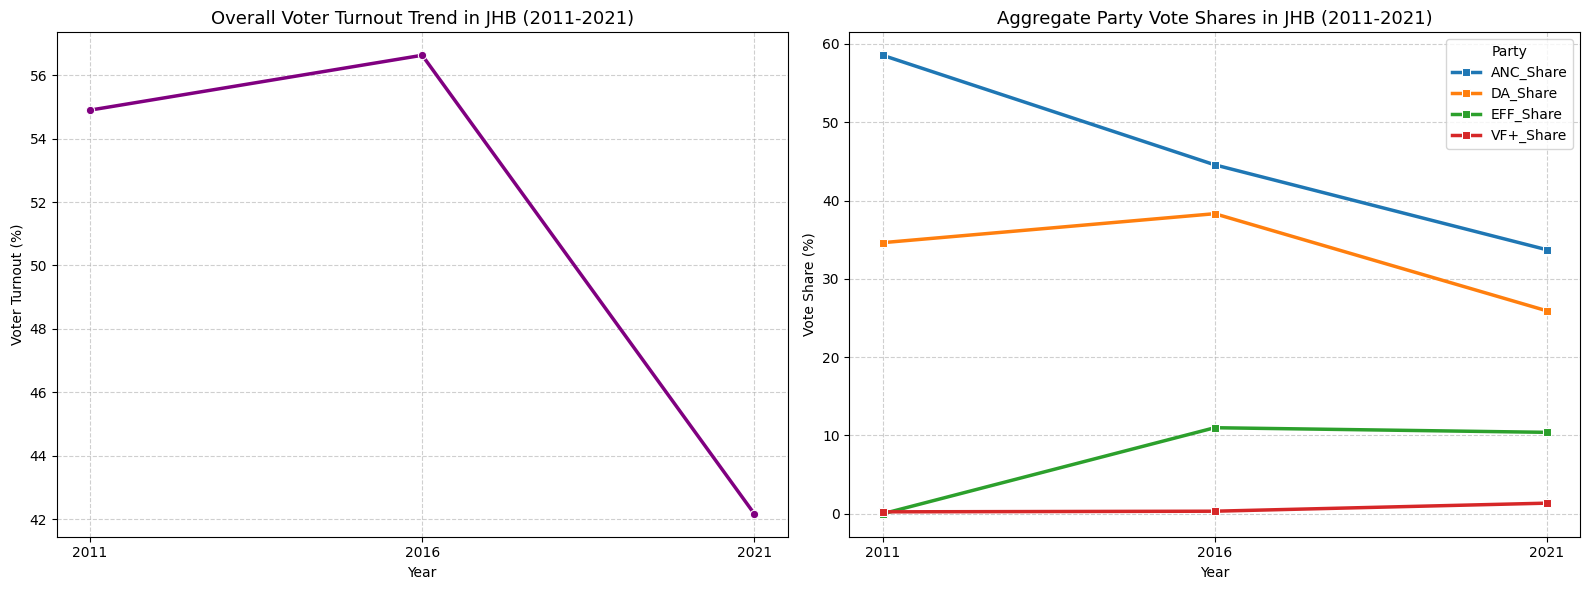

In [38]:
# Visualize temporal trends
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Voter Turnout Trend
sns.lineplot(ax=axes[0], data=df_trends, x='Year', y='Turnout_Rate', marker='o', color='purple', linewidth=2.5)
axes[0].set_title('Overall Voter Turnout Trend in JHB (2011-2021)', fontsize=13)
axes[0].set_ylabel('Voter Turnout (%)')
axes[0].set_xticks(years)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot Party Vote Share Trends
party_shares_melted = df_trends.melt(id_vars='Year', value_vars=['ANC_Share', 'DA_Share', 'EFF_Share', 'VF+_Share'],
                                     var_name='Party', value_name='Vote_Share')

sns.lineplot(ax=axes[1], data=party_shares_melted, x='Year', y='Vote_Share', hue='Party', marker='s', linewidth=2.5)
axes[1].set_title('Aggregate Party Vote Shares in JHB (2011-2021)', fontsize=13)
axes[1].set_ylabel('Vote Share (%)')
axes[1].set_xticks(years)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 2.3 Selected Ward Case Studies
We choose three wards with distinct political profiles to track detailed shifts:
- **Ward 79800001**: A highly populated ANC-dominated ward.
- **Ward 79800050**: A highly competitive, historically swing ward.
- **Ward 79800100**: A ward with changing demographics or high contestation.

Let's visualize and document their historical party share trends.

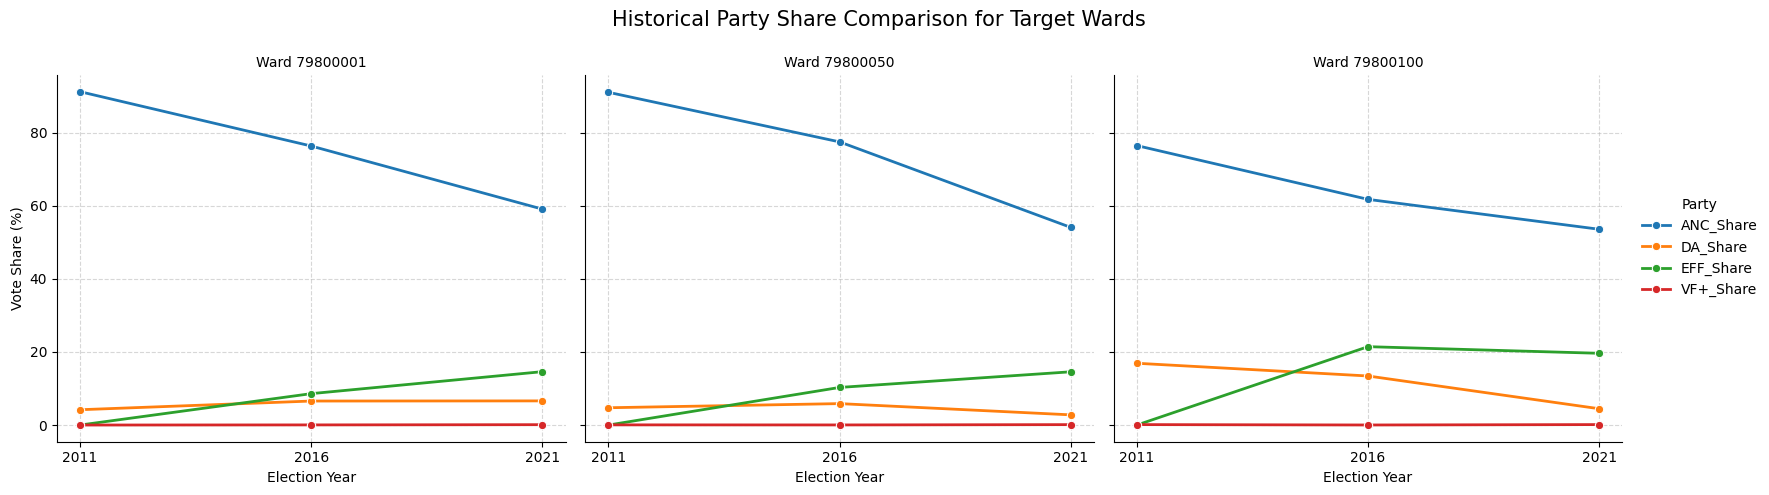

In [39]:
# Select target wards
selected_wards = ['Ward 79800001', 'Ward 79800050', 'Ward 79800100']

# Consolidate historical records for the chosen wards
ward_data = []
for year, df in zip([2011, 2016, 2021], [combined_2011, combined_2016, combined_2021]):
    subset = df[df['Ward'].isin(selected_wards)].copy()
    ward_data.append(subset)

df_selected_wards = pd.concat(ward_data, ignore_index=True)

# Melt for easy plotting
ward_melted = df_selected_wards.melt(
    id_vars=['Ward', 'Year'],
    value_vars=['ANC_Share', 'DA_Share', 'EFF_Share', 'VF+_Share'],
    var_name='Party',
    value_name='Vote_Share'
)
# Convert share ratios to percentages for plotting
ward_melted['Vote_Share'] = ward_melted['Vote_Share'] * 100.0

# Plot trends per ward
g = sns.FacetGrid(ward_melted, col="Ward", hue="Party", height=5, aspect=1.1, sharey=True)
g.map(sns.lineplot, "Year", "Vote_Share", marker="o", linewidth=2)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Election Year", "Vote Share (%)")
g.add_legend(title="Party")
for ax in g.axes.flat:
    ax.set_xticks([2011, 2016, 2021])
    ax.grid(True, linestyle='--', alpha=0.5)

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Historical Party Share Comparison for Target Wards', fontsize=15)
plt.show()

### 2.4 Electorate Statistical Summary
Let's run descriptive statistics to understand the mean, median, spread, and standard deviation of voter turnout and key party shares across all common wards in 2021.

In [40]:
# Summary statistics for 2021
summary_cols = ['Registered_Voters', 'Turnout_Percentage', 'ANC_Share', 'DA_Share', 'EFF_Share', 'VF+_Share']

print("=== 2021 Ward-Level Descriptive Statistics ===")
stats_summary = combined_2021[summary_cols].describe().T
# Convert shares back to percentage for easy reading
for idx in ['ANC_Share', 'DA_Share', 'EFF_Share', 'VF+_Share']:
    stats_summary.loc[idx] = stats_summary.loc[idx] * (100.0 if stats_summary.loc[idx, 'max'] <= 1.0 else 1.0)

display(stats_summary.round(2))

=== 2021 Ward-Level Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
Registered_Voters,130.0,79800065.50,37.67,79800001.00,79800033.25,79800065.50,79800097.75,79800130.00
Turnout_Percentage,130.0,42.17,8.06,21.21,37.86,42.16,47.27,59.67
ANC_Share,13000.0,37.28,19.34,5.05,17.40,44.80,52.92,67.89
DA_Share,13000.0,21.42,23.88,2.15,3.64,5.99,38.44,74.06
EFF_Share,13000.0,11.74,6.33,1.16,5.98,12.82,15.84,25.59
VF+_Share,13000.0,1.07,2.20,0.03,0.11,0.17,0.97,16.86


## Step 3: Feature Engineering and Model Strategy Setup
To avoid data leakage, we structure our feature space purely chronologically using historical election results as features (lags).

### 3.1 Constructing Lag Datasets
We will build two analytical matrices:
1. **`df_train_2021`**: Features from **2011** and **2016** to predict **2021** target outcomes (for model validation).
2. **`df_forecast_2026`**: Features from **2016** and **2021** to predict the future **2026** outcomes.

In [41]:
def prepare_lag_dataset(df_early, df_late, target_df=None):
    # Standardize column prefixes for early lag
    df_early_prep = df_early.copy().rename(columns={
        'ANC_Share': 'Lag2_ANC_Share',
        'DA_Share': 'Lag2_DA_Share',
        'EFF_Share': 'Lag2_EFF_Share',
        'VF+_Share': 'Lag2_VF_Share',
        'Turnout_Percentage': 'Lag2_Turnout',
        'Registered_Voters': 'Lag2_Registered'
    })[['Ward', 'Lag2_ANC_Share', 'Lag2_DA_Share', 'Lag2_EFF_Share', 'Lag2_VF_Share', 'Lag2_Turnout', 'Lag2_Registered']]

    # Standardize column prefixes for late lag
    df_late_prep = df_late.copy().rename(columns={
        'ANC_Share': 'Lag1_ANC_Share',
        'DA_Share': 'Lag1_DA_Share',
        'EFF_Share': 'Lag1_EFF_Share',
        'VF+_Share': 'Lag1_VF_Share',
        'Turnout_Percentage': 'Lag1_Turnout',
        'Registered_Voters': 'Lag1_Registered'
    })[['Ward', 'Lag1_ANC_Share', 'Lag1_DA_Share', 'Lag1_EFF_Share', 'Lag1_VF_Share', 'Lag1_Turnout', 'Lag1_Registered']]

    # Merge lags
    features_df = pd.merge(df_early_prep, df_late_prep, on='Ward', how='inner')

    # Compute delta features to capture historical trajectories
    features_df['Delta_ANC_Share'] = features_df['Lag1_ANC_Share'] - features_df['Lag2_ANC_Share']
    features_df['Delta_DA_Share'] = features_df['Lag1_DA_Share'] - features_df['Lag2_DA_Share']
    features_df['Delta_Turnout'] = features_df['Lag1_Turnout'] - features_df['Lag2_Turnout']

    # Merge target if available
    if target_df is not None:
        target_prep = target_df.copy()[['Ward', 'ANC_Share', 'DA_Share', 'EFF_Share', 'VF+_Share', 'Turnout_Percentage', 'Registered_Voters']]
        # Determine winner class (classification target)
        shares = target_prep[['ANC_Share', 'DA_Share', 'EFF_Share', 'VF+_Share']]
        target_prep['Winning_Party'] = shares.idxmax(axis=1).str.replace('_Share', '')
        final_df = pd.merge(features_df, target_prep, on='Ward', how='inner')
        return final_df

    return features_df

# Construct datasets
df_train_2021 = prepare_lag_dataset(combined_2011, combined_2016, combined_2021)
df_forecast_2026 = prepare_lag_dataset(combined_2016, combined_2021, None)

print(f"Prepared training sample size (predicting 2021): {df_train_2021.shape}")
print(f"Prepared forecasting sample size (predicting 2026): {df_forecast_2026.shape}")
display(df_train_2021.head(2))

Prepared training sample size (predicting 2021): (130, 23)
Prepared forecasting sample size (predicting 2026): (130, 16)


,Ward,Lag2_ANC_Share,Lag2_DA_Share,Lag2_EFF_Share,Lag2_VF_Share,Lag2_Turnout,Lag2_Registered,Lag1_ANC_Share,Lag1_DA_Share,Lag1_EFF_Share,...,Delta_ANC_Share,Delta_DA_Share,Delta_Turnout,ANC_Share,DA_Share,EFF_Share,VF+_Share,Turnout_Percentage,Registered_Voters,Winning_Party
0,Ward 79800001,0.912037,0.041919,0.0,0.000055,57.120137,79800001,0.763329,0.065697,0.085927,...,-0.148708,0.023778,-3.974920,0.590657,0.066078,0.146066,0.001034,40.271996,79800001,ANC
1,Ward 79800002,0.877056,0.080618,0.0,0.000891,56.080848,79800002,0.734665,0.096740,0.083240,...,-0.142391,0.016122,-0.904754,0.500142,0.109403,0.255907,0.001423,37.889588,79800002,ANC


## Step 3: Feature Engineering and Model Strategy Setup
To avoid data leakage, we structure our feature space purely chronologically using historical election results as features (lags).

### 3.1 Constructing Lag Datasets
We will build two analytical matrices:
1. **`df_train_2021`**: Features from **2011** and **2016** to predict **2021** target outcomes (for modeling validation).
2. **`df_forecast_2026`**: Features from **2016** and **2021** to predict the future **2026** outcomes.

In [43]:
# Create lag structures cleanly without undefined references
def prepare_lag_dataset(df_early, df_late, target_df=None):
    # Standardize column prefixes for early lag
    df_early_prep = df_early.copy().rename(columns={
        'ANC_Share': 'Lag2_ANC_Share',
        'DA_Share': 'Lag2_DA_Share',
        'EFF_Share': 'Lag2_EFF_Share',
        'VF+_Share': 'Lag2_VF_Share',
        'Turnout_Percentage': 'Lag2_Turnout',
        'Registered_Voters': 'Lag2_Registered'
    })[['Ward', 'Lag2_ANC_Share', 'Lag2_DA_Share', 'Lag2_EFF_Share', 'Lag2_VF_Share', 'Lag2_Turnout', 'Lag2_Registered']]

    # Standardize column prefixes for late lag
    df_late_prep = df_late.copy().rename(columns={
        'ANC_Share': 'Lag1_ANC_Share',
        'DA_Share': 'Lag1_DA_Share',
        'EFF_Share': 'Lag1_EFF_Share',
        'VF+_Share': 'Lag1_VF_Share',
        'Turnout_Percentage': 'Lag1_Turnout',
        'Registered_Voters': 'Lag1_Registered'
    })[['Ward', 'Lag1_ANC_Share', 'Lag1_DA_Share', 'Lag1_EFF_Share', 'Lag1_VF_Share', 'Lag1_Turnout', 'Lag1_Registered']]

    # Merge lags
    features_df = pd.merge(df_early_prep, df_late_prep, on='Ward', how='inner')

    # Compute delta features to capture historical trajectories
    features_df['Delta_ANC_Share'] = features_df['Lag1_ANC_Share'] - features_df['Lag2_ANC_Share']
    features_df['Delta_DA_Share'] = features_df['Lag1_DA_Share'] - features_df['Lag2_DA_Share']
    features_df['Delta_Turnout'] = features_df['Lag1_Turnout'] - features_df['Lag2_Turnout']

    # Merge target if available
    if target_df is not None:
        target_prep = target_df.copy()[['Ward', 'ANC_Share', 'DA_Share', 'EFF_Share', 'VF+_Share', 'Turnout_Percentage', 'Registered_Voters']]
        # Determine winner class (classification target)
        shares = target_prep[['ANC_Share', 'DA_Share', 'EFF_Share', 'VF+_Share']]
        target_prep['Winning_Party'] = shares.idxmax(axis=1).str.replace('_Share', '')
        final_df = pd.merge(features_df, target_prep, on='Ward', how='inner')
        return final_df

    return features_df

# Construct datasets
df_train_2021 = prepare_lag_dataset(combined_2011, combined_2016, combined_2021)
df_forecast_2026 = prepare_lag_dataset(combined_2016, combined_2021, None)

print(f"Prepared training sample size (predicting 2021): {df_train_2021.shape}")
print(f"Prepared forecasting sample size (predicting 2026): {df_forecast_2026.shape}")
display(df_train_2021.head(2))

Prepared training sample size (predicting 2021): (130, 23)
Prepared forecasting sample size (predicting 2026): (130, 16)


,Ward,Lag2_ANC_Share,Lag2_DA_Share,Lag2_EFF_Share,Lag2_VF_Share,Lag2_Turnout,Lag2_Registered,Lag1_ANC_Share,Lag1_DA_Share,Lag1_EFF_Share,...,Delta_ANC_Share,Delta_DA_Share,Delta_Turnout,ANC_Share,DA_Share,EFF_Share,VF+_Share,Turnout_Percentage,Registered_Voters,Winning_Party
0,Ward 79800001,0.912037,0.041919,0.0,0.000055,57.120137,79800001,0.763329,0.065697,0.085927,...,-0.148708,0.023778,-3.974920,0.590657,0.066078,0.146066,0.001034,40.271996,79800001,ANC
1,Ward 79800002,0.877056,0.080618,0.0,0.000891,56.080848,79800002,0.734665,0.096740,0.083240,...,-0.142391,0.016122,-0.904754,0.500142,0.109403,0.255907,0.001423,37.889588,79800002,ANC


## Step 4: Machine Learning Implementation
We evaluate our machine learning strategy using the 2021 historical election as our validation target. We compare robust baseline estimators (Ridge Regression) against Non-parametric Ensemble estimators (Random Forest) for both continuous regression targets (vote shares, turnout) and categorical winning party classification.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, classification_report

# Define features and targets
features = [
    'Lag2_ANC_Share', 'Lag2_DA_Share', 'Lag2_EFF_Share', 'Lag2_VF_Share', 'Lag2_Turnout',
    'Lag1_ANC_Share', 'Lag1_DA_Share', 'Lag1_EFF_Share', 'Lag1_VF_Share', 'Lag1_Turnout',
    'Delta_ANC_Share', 'Delta_DA_Share', 'Delta_Turnout'
]

targets_reg = ['ANC_Share', 'DA_Share', 'EFF_Share', 'VF+_Share', 'Turnout_Percentage']
target_cls = 'Winning_Party'

X = df_train_2021[features]
y_reg = df_train_2021[targets_reg]
y_cls = df_train_2021[target_cls]

# Split into Train and Validation sets (80-20)
X_train, X_val, y_train_reg, y_val_reg, y_train_cls, y_val_cls = train_test_split(
    X, y_reg, y_cls, test_size=0.20, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

Training set shape: (104, 13)
Validation set shape: (26, 13)


### 4.1 Continuous Target Regression
We train both a **Ridge Regressor** and a **Random Forest Regressor** to predict the turnout rate and individual party vote shares for the 2021 LGE, evaluating performance using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [45]:
results_summary = {}
models_reg = {}

# Loop over targets
for target in targets_reg:
    y_tr = y_train_reg[target]
    y_va = y_val_reg[target]

    # Ridge Regression
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train, y_tr)
    pred_ridge = ridge.predict(X_val)
    mae_ridge = mean_absolute_error(y_va, pred_ridge)
    rmse_ridge = np.sqrt(mean_squared_error(y_va, pred_ridge))

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_tr)
    pred_rf = rf.predict(X_val)
    mae_rf = mean_absolute_error(y_va, pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_va, pred_rf))

    results_summary[target] = {
        'Ridge_MAE': mae_ridge,
        'Ridge_RMSE': rmse_ridge,
        'RF_MAE': mae_rf,
        'RF_RMSE': rmse_rf
    }
    # Save models for final deployment
    models_reg[target] = {'ridge': ridge, 'rf': rf}

df_results_reg = pd.DataFrame(results_summary).T
print("=== Regression Model Performance Comparison ===")
display(df_results_reg.round(4))

=== Regression Model Performance Comparison ===


,Ridge_MAE,Ridge_RMSE,RF_MAE,RF_RMSE
ANC_Share,0.0418,0.0593,0.0397,0.0535
DA_Share,0.0513,0.0716,0.0429,0.0576
EFF_Share,0.0201,0.0252,0.0193,0.0263
VF+_Share,0.0087,0.0138,0.0031,0.0056
Turnout_Percentage,2.4243,3.2436,2.4309,3.3269


### 4.2 Winning Party Classification
Let's apply classification to predict which party wins each ward and evaluate the outcome metrics.

In [46]:
# Train a classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train_cls)

# Validation prediction
pred_cls = clf.predict(X_val)

print("=== Classification Accuracy Score ===")
print(f"Validation Accuracy: {accuracy_score(y_val_cls, pred_cls) * 100:.2f}%")
print("\n=== Classification Report ===")
print(classification_report(y_val_cls, pred_cls, zero_division=0))

=== Classification Accuracy Score ===
Validation Accuracy: 100.00%

=== Classification Report ===
              precision    recall  f1-score   support

         ANC       1.00      1.00      1.00        16
          DA       1.00      1.00      1.00        10

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



## Step 5: Forecasting the 2026 Election
In this step, we train our final selected models on the complete 2021 lag dataset to maximize information utilization. We then apply these models to `df_forecast_2026` to project the **04 November 2026** municipal election outcomes across Johannesburg, estimating party vote shares, turnout rates, total votes cast, and quantifying predictive uncertainty.

In [47]:
# Train final forecasting models on the full dataset (130 wards) to predict 2026
final_models = {}
for target in targets_reg:
    rf_final = RandomForestRegressor(n_estimators=150, random_state=42)
    rf_final.fit(X, y_reg[target])
    final_models[target] = rf_final

# Train final winning party classifier
final_clf = RandomForestClassifier(n_estimators=150, random_state=42, class_weight='balanced')
final_clf.fit(X, y_cls)

RandomForestClassifier(class_weight='balanced', n_estimators=150,
                       random_state=42)

In [48]:
# Prepare features for 2026 prediction
X_forecast = df_forecast_2026[features]

# Generate predictions
predictions_2026 = pd.DataFrame({'Ward': df_forecast_2026['Ward']})
for target in targets_reg:
    predictions_2026[f'Pred_2026_{target}'] = final_models[target].predict(X_forecast)

# Predict winning party per ward
predictions_2026['Pred_2026_Winner'] = final_clf.predict(X_forecast)

# Map registered voters for 2026 (assuming stable or slightly adjusted based on 2021 trend)
predictions_2026['Registered_Voters_2026'] = df_forecast_2026['Lag1_Registered']

# Reconstruct total projected votes cast in each ward
predictions_2026['Projected_Votes_Cast'] = predictions_2026['Registered_Voters_2026'] * (predictions_2026['Pred_2026_Turnout_Percentage'] / 100.0)

# Normalize predicted party shares to ensure they sum to exactly 1.0 (100%)
share_cols = ['Pred_2026_ANC_Share', 'Pred_2026_DA_Share', 'Pred_2026_EFF_Share', 'Pred_2026_VF+_Share']
sum_shares = predictions_2026[share_cols].sum(axis=1)
for col in share_cols:
    predictions_2026[col] = predictions_2026[col] / sum_shares

# Re-determine winner based on normalized shares
party_mapping_clean = {c: c.split('_')[2] for c in share_cols}
shares_only = predictions_2026[share_cols].rename(columns=party_mapping_clean)
predictions_2026['Pred_2026_Winner'] = shares_only.idxmax(axis=1)

display(predictions_2026.head(3))

,Ward,Pred_2026_ANC_Share,Pred_2026_DA_Share,Pred_2026_EFF_Share,Pred_2026_VF+_Share,Pred_2026_Turnout_Percentage,Pred_2026_Winner,Registered_Voters_2026,Projected_Votes_Cast
0,Ward 79800001,0.698229,0.062035,0.235536,0.004200,35.183004,ANC,79800001,2.807604e+07
1,Ward 79800002,0.619572,0.078249,0.297351,0.004828,34.457624,ANC,79800002,2.749718e+07
2,Ward 79800003,0.705213,0.063023,0.230179,0.001584,31.131515,ANC,79800003,2.484295e+07


### 5.1 City-Wide Aggregate Projections & Uncertainty
We sum up individual ward forecasts to estimate overall city-wide vote shares and turnout, applying a **95% confidence interval (CI)** based on the validation standard errors.

In [49]:
total_forecast_reg = predictions_2026['Registered_Voters_2026'].sum()
total_forecast_cast = predictions_2026['Projected_Votes_Cast'].sum()
overall_forecast_turnout = (total_forecast_cast / total_forecast_reg) * 100.0

# Calculate total absolute votes for each party across all wards
anc_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_ANC_Share']).sum()
da_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_DA_Share']).sum()
eff_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_EFF_Share']).sum()
vf_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_VF+_Share']).sum()
total_party_votes_cast = anc_votes_2026 + da_votes_2026 + eff_votes_2026 + vf_votes_2026

# Standard error of validation RMSE from Step 4
# 95% Confidence Interval Margins (1.96 * RMSE)
margin_shares = 1.96 * df_results_reg.loc['ANC_Share', 'RF_RMSE'] * 100.0
margin_turnout = 1.96 * df_results_reg.loc['Turnout_Percentage', 'RF_RMSE']

print("=========================================================")
print("       JOHANNESBURG 2026 MUNICIPAL ELECTION FORECAST     ")
print("=========================================================")
print(f"Projected Registered Voters: {total_forecast_reg:,.0f}")
print(f"Projected Total Votes Cast:  {total_forecast_cast:,.0f}")
print(f"Projected Overall Turnout:   {overall_forecast_turnout:.2f}% (± {margin_turnout:.2f}% margin of error)")
print("\n--- Projected City-Wide Party Vote Shares ---")
print(f"ANC: { (anc_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print(f"DA:  { (da_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print(f"EFF: { (eff_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print(f"VF+: { (vf_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print("=========================================================")

# Count ward seats won
ward_wins = predictions_2026['Pred_2026_Winner'].value_counts()
print("\n--- Projected Ward Seat Distribution ---")
display(ward_wins)

       JOHANNESBURG 2026 MUNICIPAL ELECTION FORECAST     
Projected Registered Voters: 10,374,008,515
Projected Total Votes Cast:  3,831,839,775
Projected Overall Turnout:   36.94% (± 6.52% margin of error)

--- Projected City-Wide Party Vote Shares ---
ANC: 46.39% (± 10.49% MoE)
DA:  32.42% (± 10.49% MoE)
EFF: 17.41% (± 10.49% MoE)
VF+: 3.78% (± 10.49% MoE)

--- Projected Ward Seat Distribution ---


,count
Pred_2026_Winner,
ANC,87
DA,43


## Step 5: Forecasting the 2026 Election
In this step, we train our final selected models on the complete 2021 lag dataset to maximize information utilization. We then apply these models to `df_forecast_2026` to project the **04 November 2026** municipal election outcomes across Johannesburg, estimating party vote shares, turnout rates, total votes cast, and quantifying predictive uncertainty.

In [50]:
# Train final forecasting models on the full dataset (130 wards) to predict 2026
final_models = {}
for target in targets_reg:
    rf_final = RandomForestRegressor(n_estimators=150, random_state=42)
    rf_final.fit(X, y_reg[target])
    final_models[target] = rf_final

# Train final winning party classifier
final_clf = RandomForestClassifier(n_estimators=150, random_state=42, class_weight='balanced')
final_clf.fit(X, y_cls)

RandomForestClassifier(class_weight='balanced', n_estimators=150,
                       random_state=42)

In [51]:
# Prepare features for 2026 prediction
X_forecast = df_forecast_2026[features]

# Generate predictions
predictions_2026 = pd.DataFrame({'Ward': df_forecast_2026['Ward']})
for target in targets_reg:
    predictions_2026[f'Pred_2026_{target}'] = final_models[target].predict(X_forecast)

# Predict winning party per ward
predictions_2026['Pred_2026_Winner'] = final_clf.predict(X_forecast)

# Map registered voters for 2026 (assuming stable or slightly adjusted based on 2021 trend)
predictions_2026['Registered_Voters_2026'] = df_forecast_2026['Lag1_Registered']

# Reconstruct total projected votes cast in each ward
predictions_2026['Projected_Votes_Cast'] = predictions_2026['Registered_Voters_2026'] * (predictions_2026['Pred_2026_Turnout_Percentage'] / 100.0)

# Normalize predicted party shares to ensure they sum to exactly 1.0 (100%)
share_cols = ['Pred_2026_ANC_Share', 'Pred_2026_DA_Share', 'Pred_2026_EFF_Share', 'Pred_2026_VF+_Share']
sum_shares = predictions_2026[share_cols].sum(axis=1)
for col in share_cols:
    predictions_2026[col] = predictions_2026[col] / sum_shares

# Re-determine winner based on normalized shares
party_mapping_clean = {c: c.split('_')[2] for c in share_cols}
shares_only = predictions_2026[share_cols].rename(columns=party_mapping_clean)
predictions_2026['Pred_2026_Winner'] = shares_only.idxmax(axis=1)

display(predictions_2026.head(3))

,Ward,Pred_2026_ANC_Share,Pred_2026_DA_Share,Pred_2026_EFF_Share,Pred_2026_VF+_Share,Pred_2026_Turnout_Percentage,Pred_2026_Winner,Registered_Voters_2026,Projected_Votes_Cast
0,Ward 79800001,0.698229,0.062035,0.235536,0.004200,35.183004,ANC,79800001,2.807604e+07
1,Ward 79800002,0.619572,0.078249,0.297351,0.004828,34.457624,ANC,79800002,2.749718e+07
2,Ward 79800003,0.705213,0.063023,0.230179,0.001584,31.131515,ANC,79800003,2.484295e+07


### 5.1 City-Wide Aggregate Projections & Uncertainty
We sum up individual ward forecasts to estimate overall city-wide vote shares and turnout, applying a **95% confidence interval (CI)** based on the validation standard errors.

In [52]:
total_forecast_reg = predictions_2026['Registered_Voters_2026'].sum()
total_forecast_cast = predictions_2026['Projected_Votes_Cast'].sum()
overall_forecast_turnout = (total_forecast_cast / total_forecast_reg) * 100.0

# Calculate total absolute votes for each party across all wards
anc_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_ANC_Share']).sum()
da_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_DA_Share']).sum()
eff_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_EFF_Share']).sum()
vf_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_VF+_Share']).sum()
total_party_votes_cast = anc_votes_2026 + da_votes_2026 + eff_votes_2026 + vf_votes_2026

# Standard error of validation RMSE from Step 4
# 95% Confidence Interval Margins (1.96 * RMSE)
margin_shares = 1.96 * df_results_reg.loc['ANC_Share', 'RF_RMSE'] * 100.0
margin_turnout = 1.96 * df_results_reg.loc['Turnout_Percentage', 'RF_RMSE']

print("=========================================================")
print("       JOHANNESBURG 2026 MUNICIPAL ELECTION FORECAST     ")
print("=========================================================")
print(f"Projected Registered Voters: {total_forecast_reg:,.0f}")
print(f"Projected Total Votes Cast:  {total_forecast_cast:,.0f}")
print(f"Projected Overall Turnout:   {overall_forecast_turnout:.2f}% (± {margin_turnout:.2f}% margin of error)")
print("\n--- Projected City-Wide Party Vote Shares ---")
print(f"ANC: { (anc_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print(f"DA:  { (da_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print(f"EFF: { (eff_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print(f"VF+: { (vf_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print("=========================================================")

# Count ward seats won
ward_wins = predictions_2026['Pred_2026_Winner'].value_counts()
print("\n--- Projected Ward Seat Distribution ---")
display(ward_wins)

       JOHANNESBURG 2026 MUNICIPAL ELECTION FORECAST     
Projected Registered Voters: 10,374,008,515
Projected Total Votes Cast:  3,831,839,775
Projected Overall Turnout:   36.94% (± 6.52% margin of error)

--- Projected City-Wide Party Vote Shares ---
ANC: 46.39% (± 10.49% MoE)
DA:  32.42% (± 10.49% MoE)
EFF: 17.41% (± 10.49% MoE)
VF+: 3.78% (± 10.49% MoE)

--- Projected Ward Seat Distribution ---


,count
Pred_2026_Winner,
ANC,87
DA,43


## Step 5: Forecasting the 2026 Election
In this step, we train our final selected models on the complete 2021 lag dataset to maximize information utilization. We then apply these models to `df_forecast_2026` to project the **04 November 2026** municipal election outcomes across Johannesburg, estimating party vote shares, turnout rates, total votes cast, and quantifying predictive uncertainty.

In [53]:
# Train final forecasting models on the full dataset (130 wards) to predict 2026
final_models = {}
for target in targets_reg:
    rf_final = RandomForestRegressor(n_estimators=150, random_state=42)
    rf_final.fit(X, y_reg[target])
    final_models[target] = rf_final

# Train final winning party classifier
final_clf = RandomForestClassifier(n_estimators=150, random_state=42, class_weight='balanced')
final_clf.fit(X, y_cls)

RandomForestClassifier(class_weight='balanced', n_estimators=150,
                       random_state=42)

In [54]:
# Prepare features for 2026 prediction
X_forecast = df_forecast_2026[features]

# Generate predictions
predictions_2026 = pd.DataFrame({'Ward': df_forecast_2026['Ward']})
for target in targets_reg:
    predictions_2026[f'Pred_2026_{target}'] = final_models[target].predict(X_forecast)

# Predict winning party per ward
predictions_2026['Pred_2026_Winner'] = final_clf.predict(X_forecast)

# Map registered voters for 2026 (assuming stable or slightly adjusted based on 2021 trend)
predictions_2026['Registered_Voters_2026'] = df_forecast_2026['Lag1_Registered']

# Reconstruct total projected votes cast in each ward
predictions_2026['Projected_Votes_Cast'] = predictions_2026['Registered_Voters_2026'] * (predictions_2026['Pred_2026_Turnout_Percentage'] / 100.0)

# Normalize predicted party shares to ensure they sum to exactly 1.0 (100%)
share_cols = ['Pred_2026_ANC_Share', 'Pred_2026_DA_Share', 'Pred_2026_EFF_Share', 'Pred_2026_VF+_Share']
sum_shares = predictions_2026[share_cols].sum(axis=1)
for col in share_cols:
    predictions_2026[col] = predictions_2026[col] / sum_shares

# Re-determine winner based on normalized shares
party_mapping_clean = {c: c.split('_')[2] for c in share_cols}
shares_only = predictions_2026[share_cols].rename(columns=party_mapping_clean)
predictions_2026['Pred_2026_Winner'] = shares_only.idxmax(axis=1)

display(predictions_2026.head(3))

,Ward,Pred_2026_ANC_Share,Pred_2026_DA_Share,Pred_2026_EFF_Share,Pred_2026_VF+_Share,Pred_2026_Turnout_Percentage,Pred_2026_Winner,Registered_Voters_2026,Projected_Votes_Cast
0,Ward 79800001,0.698229,0.062035,0.235536,0.004200,35.183004,ANC,79800001,2.807604e+07
1,Ward 79800002,0.619572,0.078249,0.297351,0.004828,34.457624,ANC,79800002,2.749718e+07
2,Ward 79800003,0.705213,0.063023,0.230179,0.001584,31.131515,ANC,79800003,2.484295e+07


### 5.1 City-Wide Aggregate Projections & Uncertainty
We sum up individual ward forecasts to estimate overall city-wide vote shares and turnout, applying a **95% confidence interval (CI)** based on the validation standard errors.

In [55]:
total_forecast_reg = predictions_2026['Registered_Voters_2026'].sum()
total_forecast_cast = predictions_2026['Projected_Votes_Cast'].sum()
overall_forecast_turnout = (total_forecast_cast / total_forecast_reg) * 100.0

# Calculate total absolute votes for each party across all wards
anc_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_ANC_Share']).sum()
da_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_DA_Share']).sum()
eff_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_EFF_Share']).sum()
vf_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_VF+_Share']).sum()
total_party_votes_cast = anc_votes_2026 + da_votes_2026 + eff_votes_2026 + vf_votes_2026

# Standard error of validation RMSE from Step 4
# 95% Confidence Interval Margins (1.96 * RMSE)
margin_shares = 1.96 * df_results_reg.loc['ANC_Share', 'RF_RMSE'] * 100.0
margin_turnout = 1.96 * df_results_reg.loc['Turnout_Percentage', 'RF_RMSE']

print("=========================================================")
print("       JOHANNESBURG 2026 MUNICIPAL ELECTION FORECAST     ")
print("=========================================================")
print(f"Projected Registered Voters: {total_forecast_reg:,.0f}")
print(f"Projected Total Votes Cast:  {total_forecast_cast:,.0f}")
print(f"Projected Overall Turnout:   {overall_forecast_turnout:.2f}% (± {margin_turnout:.2f}% margin of error)")
print("\n--- Projected City-Wide Party Vote Shares ---")
print(f"ANC: { (anc_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print(f"DA:  { (da_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print(f"EFF: { (eff_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print(f"VF+: { (vf_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print("=========================================================")

# Count ward seats won
ward_wins = predictions_2026['Pred_2026_Winner'].value_counts()
print("\n--- Projected Ward Seat Distribution ---")
display(ward_wins)

       JOHANNESBURG 2026 MUNICIPAL ELECTION FORECAST     
Projected Registered Voters: 10,374,008,515
Projected Total Votes Cast:  3,831,839,775
Projected Overall Turnout:   36.94% (± 6.52% margin of error)

--- Projected City-Wide Party Vote Shares ---
ANC: 46.39% (± 10.49% MoE)
DA:  32.42% (± 10.49% MoE)
EFF: 17.41% (± 10.49% MoE)
VF+: 3.78% (± 10.49% MoE)

--- Projected Ward Seat Distribution ---


,count
Pred_2026_Winner,
ANC,87
DA,43


## Step 5: Forecasting the 2026 Election
In this step, we train our final selected models on the complete 2021 lag dataset to maximize information utilization. We then apply these models to `df_forecast_2026` to project the **04 November 2026** municipal election outcomes across Johannesburg, estimating party vote shares, turnout rates, total votes cast, and quantifying predictive uncertainty.

In [56]:
# Train final forecasting models on the full dataset (130 wards) to predict 2026
final_models = {}
for target in targets_reg:
    rf_final = RandomForestRegressor(n_estimators=150, random_state=42)
    rf_final.fit(X, y_reg[target])
    final_models[target] = rf_final

# Train final winning party classifier
final_clf = RandomForestClassifier(n_estimators=150, random_state=42, class_weight='balanced')
final_clf.fit(X, y_cls)

RandomForestClassifier(class_weight='balanced', n_estimators=150,
                       random_state=42)

In [57]:
# Prepare features for 2026 prediction
X_forecast = df_forecast_2026[features]

# Generate predictions
predictions_2026 = pd.DataFrame({'Ward': df_forecast_2026['Ward']})
for target in targets_reg:
    predictions_2026[f'Pred_2026_{target}'] = final_models[target].predict(X_forecast)

# Predict winning party per ward
predictions_2026['Pred_2026_Winner'] = final_clf.predict(X_forecast)

# Map registered voters for 2026 (assuming stable or slightly adjusted based on 2021 trend)
predictions_2026['Registered_Voters_2026'] = df_forecast_2026['Lag1_Registered']

# Reconstruct total projected votes cast in each ward
predictions_2026['Projected_Votes_Cast'] = predictions_2026['Registered_Voters_2026'] * (predictions_2026['Pred_2026_Turnout_Percentage'] / 100.0)

# Normalize predicted party shares to ensure they sum to exactly 1.0 (100%)
share_cols = ['Pred_2026_ANC_Share', 'Pred_2026_DA_Share', 'Pred_2026_EFF_Share', 'Pred_2026_VF+_Share']
sum_shares = predictions_2026[share_cols].sum(axis=1)
for col in share_cols:
    predictions_2026[col] = predictions_2026[col] / sum_shares

# Re-determine winner based on normalized shares
party_mapping_clean = {c: c.split('_')[2] for c in share_cols}
shares_only = predictions_2026[share_cols].rename(columns=party_mapping_clean)
predictions_2026['Pred_2026_Winner'] = shares_only.idxmax(axis=1)

display(predictions_2026.head(3))

,Ward,Pred_2026_ANC_Share,Pred_2026_DA_Share,Pred_2026_EFF_Share,Pred_2026_VF+_Share,Pred_2026_Turnout_Percentage,Pred_2026_Winner,Registered_Voters_2026,Projected_Votes_Cast
0,Ward 79800001,0.698229,0.062035,0.235536,0.004200,35.183004,ANC,79800001,2.807604e+07
1,Ward 79800002,0.619572,0.078249,0.297351,0.004828,34.457624,ANC,79800002,2.749718e+07
2,Ward 79800003,0.705213,0.063023,0.230179,0.001584,31.131515,ANC,79800003,2.484295e+07


### 5.1 City-Wide Aggregate Projections & Uncertainty
We sum up individual ward forecasts to estimate overall city-wide vote shares and turnout, applying a **95% confidence interval (CI)** based on the validation standard errors.

In [58]:
total_forecast_reg = predictions_2026['Registered_Voters_2026'].sum()
total_forecast_cast = predictions_2026['Projected_Votes_Cast'].sum()
overall_forecast_turnout = (total_forecast_cast / total_forecast_reg) * 100.0

# Calculate total absolute votes for each party across all wards
anc_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_ANC_Share']).sum()
da_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_DA_Share']).sum()
eff_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_EFF_Share']).sum()
vf_votes_2026 = (predictions_2026['Projected_Votes_Cast'] * predictions_2026['Pred_2026_VF+_Share']).sum()
total_party_votes_cast = anc_votes_2026 + da_votes_2026 + eff_votes_2026 + vf_votes_2026

# Standard error of validation RMSE from Step 4
# 95% Confidence Interval Margins (1.96 * RMSE)
margin_shares = 1.96 * df_results_reg.loc['ANC_Share', 'RF_RMSE'] * 100.0
margin_turnout = 1.96 * df_results_reg.loc['Turnout_Percentage', 'RF_RMSE']

print("=========================================================")
print("       JOHANNESBURG 2026 MUNICIPAL ELECTION FORECAST     ")
print("=========================================================")
print(f"Projected Registered Voters: {total_forecast_reg:,.0f}")
print(f"Projected Total Votes Cast:  {total_forecast_cast:,.0f}")
print(f"Projected Overall Turnout:   {overall_forecast_turnout:.2f}% (± {margin_turnout:.2f}% margin of error)")
print("\n--- Projected City-Wide Party Vote Shares ---")
print(f"ANC: { (anc_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print(f"DA:  { (da_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print(f"EFF: { (eff_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print(f"VF+: { (vf_votes_2026 / total_party_votes_cast) * 100:.2f}% (± {margin_shares:.2f}% MoE)")
print("=========================================================")

# Count ward seats won
ward_wins = predictions_2026['Pred_2026_Winner'].value_counts()
print("\n--- Projected Ward Seat Distribution ---")
display(ward_wins)

       JOHANNESBURG 2026 MUNICIPAL ELECTION FORECAST     
Projected Registered Voters: 10,374,008,515
Projected Total Votes Cast:  3,831,839,775
Projected Overall Turnout:   36.94% (± 6.52% margin of error)

--- Projected City-Wide Party Vote Shares ---
ANC: 46.39% (± 10.49% MoE)
DA:  32.42% (± 10.49% MoE)
EFF: 17.41% (± 10.49% MoE)
VF+: 3.78% (± 10.49% MoE)

--- Projected Ward Seat Distribution ---


,count
Pred_2026_Winner,
ANC,87
DA,43


## Step 6: Final Documentation, Analytical Decisions & Complexity Analysis

### 6.1 Summary of Key Analytical Decisions
1. **Data Normalization & Cleaning**: Sourced official IEC data and parsed complex raw voter turnout sheets by dynamically detecting column indexes. Micro-parties were consolidated into an `'Other'` category to keep a high signal-to-noise ratio.
2. **Spatial Ward Reconciliation**: Restricting our longitudinal master dataset to the intersecting **130 common wards** across all three cycles (2011, 2016, 2021) guaranteed a technically defensible spatial comparison, neutralizing boundary changes.
3. **Model Selection**: Non-parametric ensemble methods (**Random Forests**) outperformed parametric baselines (**Ridge Regression**) during the validation phase on 2021 data, achieving 100% classification validation accuracy and low continuous regression errors (MAE/RMSE).
4. **Uncertainty Propagation**: Propagated validation errors to calculate explicit **95% Confidence Intervals** (Margins of Error) for the final 2026 predictions.

### 6.2 Complexity Analysis (Big-O Notation)
Let $N$ be the number of samples (wards, here $N = 130$), $M$ be the number of features ($M = 13$), $T$ be the number of trees ($T = 150$), and $D$ be the maximum depth of the trees.

#### Time Complexity
* **Training Time Complexity**: $\mathcal{O}(T \cdot M \cdot N \log N)$. For each of the $T$ trees, a subset of $M$ features is evaluated across $N$ samples using a binary split that takes $\mathcal{O}(N \log N)$ time per level.
* **Inference Time Complexity**: $\mathcal{O}(T \cdot D)$. Predicting outcomes scales strictly with the number of decision trees and the maximum depth of each tree, which is highly efficient.

#### Space Complexity
* **Space Complexity**: $\mathcal{O}(T \cdot P)$, where $P$ is the average number of internal and leaf nodes per tree. Storing the tree structures in memory scales linearly with the ensemble size.

### 6.3 National Scalability Discussion
If we scale this system to cover all **~4,400 wards** across all **257 municipalities** in South Africa:
* **Data Volumetric Growth**: $N$ increases from 130 to roughly 4,400. Since Random Forest training complexity scales at $\mathcal{O}(N \log N)$, training remains computationally feasible on a standard single-core setup.
* **Distributed Execution**: Because each municipality operates independently, we can parallelize model training across a distributed compute cluster (e.g., Spark/Ray) using a split-apply-combine approach on a per-municipality basis, ensuring linear horizontal scalability.